In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [23]:
data = pd.read_csv("../data/Dataset.txt", sep="\t")

In [24]:
data.columns

Index(['Age recode with <1 year olds and 90+', 'Sex', 'Year of diagnosis',
       'Race recode (W, B, AI, API)', 'Primary Site - labeled',
       'Summary stage 2000 (1998-2017)', 'Survival months',
       'Vital status recode (study cutoff used)',
       'Median household income inflation adj to 2024'],
      dtype='str')

In [25]:
data.columns = [
    "Age", "Sex", "Year", "Race", "Cancer_Type",
    "Stage", "Survival_Months", "Vital_Status", "Income"
]
print("Shape del dataset:", data.shape)

Shape del dataset: (50603, 9)


In [26]:
# Reemplazar valores no disponibles por NaN
data["Stage"] = data["Stage"].replace(["Blank(s)"],np.nan)
data["Income"] = data["Income"].replace("Unknown/missing/no match/Not 1990-2024",np.nan)
print("Valores faltantes por columna:")
print(data.isnull().sum())
print("\nCantidad de filas duplicadas:")
print(data.duplicated().sum())

Valores faltantes por columna:
Age                    0
Sex                    0
Year                   0
Race                   0
Cancer_Type            0
Stage              35786
Survival_Months        0
Vital_Status           0
Income                 6
dtype: int64

Cantidad de filas duplicadas:
3435


In [27]:
data = data.drop_duplicates()

In [28]:
data["Survival_Months"] = pd.to_numeric(
    data["Survival_Months"],
    errors="coerce"
)

In [29]:
data["Stage"] = data["Stage"].fillna("Unknown/unstaged")

In [30]:
data["Income"] = data["Income"].fillna("Unknown")


In [32]:
print("Valores faltantes por columna:")
print(data.isnull().sum())

print("\nCantidad de filas duplicadas:")
print(data.duplicated().sum())

print("\nTipos de datos:")
print(data.dtypes)

Valores faltantes por columna:
Age                  0
Sex                  0
Year                 0
Race                 0
Cancer_Type          0
Stage                0
Survival_Months    101
Vital_Status         0
Income               0
dtype: int64

Cantidad de filas duplicadas:
0

Tipos de datos:
Age                    str
Sex                    str
Year                 int64
Race                   str
Cancer_Type            str
Stage                  str
Survival_Months    float64
Vital_Status           str
Income                 str
dtype: object


In [33]:
data['Survival_Months'].describe()

count    47067.000000
mean        59.655937
std         42.840599
min          0.000000
25%         20.000000
50%         55.000000
75%         96.000000
max        143.000000
Name: Survival_Months, dtype: float64

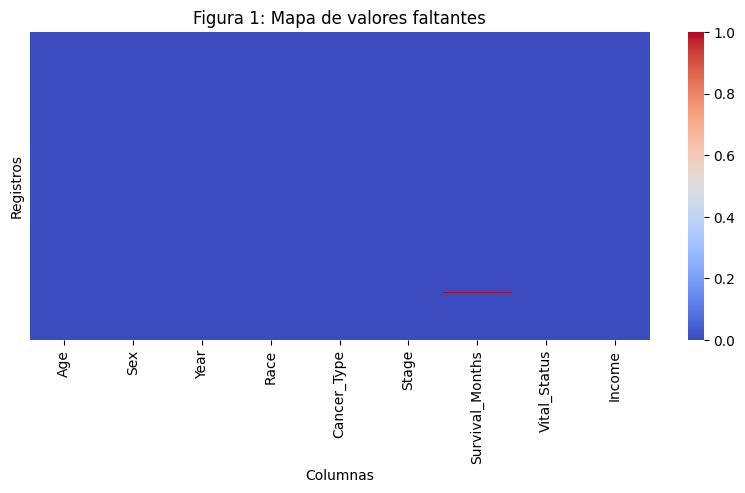

In [34]:
plt.figure(figsize=(10, 4))
sns.heatmap(data.isnull(), cbar=True, cmap="coolwarm", yticklabels=False)
plt.title("Figura 1: Mapa de valores faltantes")
plt.xlabel("Columnas")
plt.ylabel("Registros")
plt.show()

In [36]:
data = data.dropna(subset=["Survival_Months"])

In [37]:
def asignar_prioridad(row):
    if (row["Stage"] == "Distant" or row["Vital_Status"] == "Dead" or row["Survival_Months"] < 12):
        return "Alta"

    elif (row["Stage"] == "Regional" or row["Survival_Months"] < 36):
        return "Media"

    else:
        return "Baja"

data["Prioridad"] = data.apply(asignar_prioridad,axis=1)

In [39]:
top_cancers = data["Cancer_Type"].value_counts().head(15).index

data["Cancer_Type_Group"] = data["Cancer_Type"].apply(
        lambda x:
        x if x in top_cancers else "Other"
)

In [51]:
data_model = pd.get_dummies(
    data,
    columns=[
        "Age",
        "Sex",
        "Race",
        "Stage",
        "Vital_Status",
        "Income",
        "Cancer_Type_Group"
    ],
    drop_first=True
)

In [52]:
data_model = data_model.drop(
    columns=["Cancer_Type"]
)

In [47]:
data_model.to_csv("data_modelo_clinico.csv",index=False)

print("Dataset guardado correctamente")

Dataset guardado correctamente
